In [1]:
from rdflib import Graph, URIRef, Literal, Namespace, RDF
from collections import Counter
import pandas as pd

In [2]:
g = Graph()
g.parse("mutag-hetero/mutag_stripped.nt", format="nt")
train_df = pd.read_csv("mutag-hetero/trainingSet.tsv", sep="\t")
test_df = pd.read_csv("mutag-hetero/testSet.tsv", sep="\t")

In [3]:
c_df = pd.read_csv('mutag-hetero/completeDataset.tsv', sep='\t')
c_df.label_mutagenic.value_counts()

label_mutagenic
0    211
1    129
Name: count, dtype: int64

In [4]:
# data exploration
print(f"Number of triples in the graph: {len(g)}")
print("Namespaces in the graph:")
for prefix, namespace in g.namespaces():
    print(f"{prefix}: {namespace}")

Number of triples in the graph: 74227
Namespaces in the graph:
brick: https://brickschema.org/schema/Brick#
csvw: http://www.w3.org/ns/csvw#
dc: http://purl.org/dc/elements/1.1/
dcat: http://www.w3.org/ns/dcat#
dcmitype: http://purl.org/dc/dcmitype/
dcterms: http://purl.org/dc/terms/
dcam: http://purl.org/dc/dcam/
doap: http://usefulinc.com/ns/doap#
foaf: http://xmlns.com/foaf/0.1/
geo: http://www.opengis.net/ont/geosparql#
odrl: http://www.w3.org/ns/odrl/2/
org: http://www.w3.org/ns/org#
prof: http://www.w3.org/ns/dx/prof/
prov: http://www.w3.org/ns/prov#
qb: http://purl.org/linked-data/cube#
schema: https://schema.org/
sh: http://www.w3.org/ns/shacl#
skos: http://www.w3.org/2004/02/skos/core#
sosa: http://www.w3.org/ns/sosa/
ssn: http://www.w3.org/ns/ssn/
time: http://www.w3.org/2006/time#
vann: http://purl.org/vocab/vann/
void: http://rdfs.org/ns/void#
wgs: https://www.w3.org/2003/01/geo/wgs84_pos#
owl: http://www.w3.org/2002/07/owl#
rdf: http://www.w3.org/1999/02/22-rdf-syntax-ns#


In [5]:
print("Sample triples in the graph:")
for s, p, o in g:  # Display first 5 triples
    print(f"{s} - {p} - {o}")   
    break

Sample triples in the graph:
http://dl-learner.org/carcinogenesis#bond3171 - http://dl-learner.org/carcinogenesis#inBond - http://dl-learner.org/carcinogenesis#d188d_12


In [6]:
print(f"Total triples: {len(g)}")
print(f"Subjects: {len(set(g.subjects()))}")
print(f"Predicates: {len(set(g.predicates()))}")
print(f"Objects: {len(set(g.objects()))}")

Total triples: 74227
Subjects: 22534
Predicates: 23
Objects: 23281


In [7]:
# Discover all namespaces/ontologies used
namespaces = {}

# Discover all predicates used
predicates = Counter()
for s, p, o in g:
    # Extract local name from predicate URI
    predicate_name = str(p).split('#')[-1].split('/')[-1]
    predicates[predicate_name] += 1

print("\n=== Predicate Distribution ===")
for pred, count in predicates.most_common():
    print(f"{pred}: {count}")


=== Predicate Distribution ===
type: 22534
inBond: 18634
hasBond: 9317
charge: 9189
hasAtom: 9189
hasStructure: 3526
amesTestPositive: 340
salmonella: 305
cytogen_ca: 293
cytogen_sce: 283
mouse_lymph: 203
subClassOf: 138
salmonella_n: 61
chromaberr: 55
chromex: 35
drosophila_rt: 25
drosophila_slrl: 25
range: 19
domain: 19
micronuc_m: 13
micronuc_f: 13
disjointWith: 6
salmonella_reduc: 5


In [8]:
set(g.predicates())

{rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#amesTestPositive'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#charge'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#chromaberr'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#chromex'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#cytogen_ca'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#cytogen_sce'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#drosophila_rt'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#drosophila_slrl'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#hasAtom'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#hasBond'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#hasStructure'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#inBond'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#micronuc_f'),
 rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#micron

In [9]:
# calculate how many time does each node appear as a subject and as an object
subject_counts = Counter(g.subjects())
object_counts = Counter(g.objects())

In [10]:
print("\n=== Subject Counts ===")
for subject, count in subject_counts.most_common(20):
    print(f"{subject}: {count}")


=== Subject Counts ===
http://dl-learner.org/carcinogenesis#d297: 469
http://dl-learner.org/carcinogenesis#d186: 407
http://dl-learner.org/carcinogenesis#d107: 335
http://dl-learner.org/carcinogenesis#d330: 230
http://dl-learner.org/carcinogenesis#d246: 226
http://dl-learner.org/carcinogenesis#d231: 224
http://dl-learner.org/carcinogenesis#d137: 219
http://dl-learner.org/carcinogenesis#d322: 219
http://dl-learner.org/carcinogenesis#d329: 207
http://dl-learner.org/carcinogenesis#d84: 189
http://dl-learner.org/carcinogenesis#d147: 175
http://dl-learner.org/carcinogenesis#d77: 169
http://dl-learner.org/carcinogenesis#d188: 165
http://dl-learner.org/carcinogenesis#d225: 164
http://dl-learner.org/carcinogenesis#d173: 163
http://dl-learner.org/carcinogenesis#d208_2: 162
http://dl-learner.org/carcinogenesis#d144: 156
http://dl-learner.org/carcinogenesis#d66: 155
http://dl-learner.org/carcinogenesis#d155: 155
http://dl-learner.org/carcinogenesis#d183: 154


In [11]:
print("\n=== Object Counts ===")
for object, count in object_counts.most_common(20):
    print(f"{object}: {count}")


=== Object Counts ===
http://dl-learner.org/carcinogenesis#Bond-1: 6781
http://dl-learner.org/carcinogenesis#Hydrogen-3: 3632
http://dl-learner.org/carcinogenesis#Bond-7: 2067
http://dl-learner.org/carcinogenesis#Carbon-22: 1841
http://dl-learner.org/carcinogenesis#Carbon-10: 1162
true: 856
false: 800
http://dl-learner.org/carcinogenesis#Bond-2: 463
http://dl-learner.org/carcinogenesis#Six_ring: 446
http://dl-learner.org/carcinogenesis#Methyl: 378
http://dl-learner.org/carcinogenesis#Non_ar_6c_ring: 365
http://dl-learner.org/carcinogenesis#Compound: 357
http://dl-learner.org/carcinogenesis#Hydrogen-1: 355
http://dl-learner.org/carcinogenesis#Ether: 336
http://dl-learner.org/carcinogenesis#Ar_halide: 320
http://dl-learner.org/carcinogenesis#Chlorine-93: 281
http://dl-learner.org/carcinogenesis#Oxygen-40: 246
http://dl-learner.org/carcinogenesis#Nitrogen-32: 242
0.05: 196
http://dl-learner.org/carcinogenesis#Amine: 181


In [12]:
# figure out what does carcinogenisis#d297 etc refer to, and what are the other nodes that are connected to it
target_node = URIRef("http://dl-learner.org/carcinogenesis#d66")
# target_predicate = URIRef("http://dl-learner.org/carcinogenesis#hasAtom")
# target_predicate = URIRef("http://dl-learner.org/carcinogenesis#hasStructure")

print(f"\n=== Triples involving {target_node} ===")
unique_related_nodes = set()   
count = 0 
for s, p, o in g.triples((target_node, None, None)):
    if p not in unique_related_nodes:
        unique_related_nodes.add(p)
        print(f"{s} - {p} - {o}")
    # print(f"{s} - {p} - {o}")
    # count = count +  1
# print(unique_related_nodes)


=== Triples involving http://dl-learner.org/carcinogenesis#d66 ===
http://dl-learner.org/carcinogenesis#d66 - http://dl-learner.org/carcinogenesis#hasAtom - http://dl-learner.org/carcinogenesis#d66_14
http://dl-learner.org/carcinogenesis#d66 - http://dl-learner.org/carcinogenesis#hasBond - http://dl-learner.org/carcinogenesis#bond8336
http://dl-learner.org/carcinogenesis#d66 - http://dl-learner.org/carcinogenesis#hasStructure - http://dl-learner.org/carcinogenesis#ethoxy-3457
http://dl-learner.org/carcinogenesis#d66 - http://dl-learner.org/carcinogenesis#amesTestPositive - false
http://dl-learner.org/carcinogenesis#d66 - http://dl-learner.org/carcinogenesis#salmonella - false
http://dl-learner.org/carcinogenesis#d66 - http://dl-learner.org/carcinogenesis#cytogen_ca - true
http://dl-learner.org/carcinogenesis#d66 - http://dl-learner.org/carcinogenesis#cytogen_sce - true
http://dl-learner.org/carcinogenesis#d66 - http://dl-learner.org/carcinogenesis#mouse_lymph - true
http://dl-learner.

In [13]:
# Quick audit - run this once
molecule_uri = URIRef("http://dl-learner.org/carcinogenesis#d66")
hasAtom_uri = URIRef("http://dl-learner.org/carcinogenesis#hasAtom")
for atom_uri in list(g.objects(molecule_uri, hasAtom_uri))[:3]:
    print(f"\n=== {atom_uri} ===")
    for p, o in g.predicate_objects(atom_uri):
        print(p , o)


=== http://dl-learner.org/carcinogenesis#d66_14 ===
http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://dl-learner.org/carcinogenesis#Carbon-14
http://dl-learner.org/carcinogenesis#charge 0.597

=== http://dl-learner.org/carcinogenesis#d66_9 ===
http://dl-learner.org/carcinogenesis#charge -0.303
http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://dl-learner.org/carcinogenesis#Oxygen-53

=== http://dl-learner.org/carcinogenesis#d66_43 ===
http://dl-learner.org/carcinogenesis#charge 0.048
http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://dl-learner.org/carcinogenesis#Hydrogen-3


In [14]:
count = 0
for _, row in train_df.iterrows():
    graph_uri = row['bond']
    label = row['label_mutagenic']
    target_uri = URIRef(graph_uri)
    target_predicate = URIRef("http://dl-learner.org/carcinogenesis#hasStructure")
    target_predicate = URIRef("http://dl-learner.org/carcinogenesis#hasAtom")
    
    print(f"\n=== Triples involving {target_uri} ===")
    for s, p, o in g.triples((target_uri, target_predicate, None)):
        # for each hasAtom which atoms they are 
        new_target = o # which will be subject for next query
        print(f"\n *** Triples involving {new_target} ***")
        for s, p, o in g.triples((new_target, None, None)):
            print(f"{s} - {p} - {o}")



=== Triples involving http://dl-learner.org/carcinogenesis#d187 ===

 *** Triples involving http://dl-learner.org/carcinogenesis#d187_16 ***
http://dl-learner.org/carcinogenesis#d187_16 - http://www.w3.org/1999/02/22-rdf-syntax-ns#type - http://dl-learner.org/carcinogenesis#Nitrogen-36
http://dl-learner.org/carcinogenesis#d187_16 - http://dl-learner.org/carcinogenesis#charge - -0.29

 *** Triples involving http://dl-learner.org/carcinogenesis#d187_15 ***
http://dl-learner.org/carcinogenesis#d187_15 - http://dl-learner.org/carcinogenesis#charge - 0.059
http://dl-learner.org/carcinogenesis#d187_15 - http://www.w3.org/1999/02/22-rdf-syntax-ns#type - http://dl-learner.org/carcinogenesis#Hydrogen-3

 *** Triples involving http://dl-learner.org/carcinogenesis#d187_7 ***
http://dl-learner.org/carcinogenesis#d187_7 - http://www.w3.org/1999/02/22-rdf-syntax-ns#type - http://dl-learner.org/carcinogenesis#Hydrogen-3
http://dl-learner.org/carcinogenesis#d187_7 - http://dl-learner.org/carcinogenes

In [15]:
# inspect what does value of hasAtom refer to, and what are the other nodes that are connected to it
# http://dl-learner.org/carcinogenesis#d297_174
# target_node = URIRef("http://dl-learner.org/carcinogenesis#d297_174")
# target_node = URIRef("http://dl-learner.org/carcinogenesis#bond6063")
target_predicate = URIRef("http://dl-learner.org/carcinogenesis#hasAtom")
target_node = URIRef("http://dl-learner.org/carcinogenesis#ether-2066")
print(f"\n=== Triples involving {target_node} ===")
for s, p, o in g.triples((target_node, None, None)):
    print(f"{s} - {p} - {o}")
    


=== Triples involving http://dl-learner.org/carcinogenesis#ether-2066 ===
http://dl-learner.org/carcinogenesis#ether-2066 - http://www.w3.org/1999/02/22-rdf-syntax-ns#type - http://dl-learner.org/carcinogenesis#Ether


In [16]:
target_node = URIRef("http://dl-learner.org/carcinogenesis#d297_38")
# predicate and objects 
for s, p, o in g.triples((target_node, None, None)):
    print(f"{s} - {p} - {o}")

http://dl-learner.org/carcinogenesis#d297_38 - http://www.w3.org/1999/02/22-rdf-syntax-ns#type - http://dl-learner.org/carcinogenesis#Carbon-10
http://dl-learner.org/carcinogenesis#d297_38 - http://dl-learner.org/carcinogenesis#charge - 0.029


In [17]:
# rebuild one molecule from the atoms and bonds, and check if it is the same as the original molecule
target_node = URIRef("http://dl-learner.org/carcinogenesis#d183")


In [18]:
CARC = Namespace("http://dl-learner.org/carcinogenesis#")

atoms = {}

for atom in g.objects(target_node, CARC.hasAtom):
    atom_type = next(g.objects(atom, RDF.type), None)

    atoms[atom] = atom_type

print(len(atoms))

57


In [19]:
bonds = []

for bond in g.objects(target_node, CARC.hasBond):

    bond_type = next(g.objects(bond, RDF.type), None)

    endpoints = list(g.objects(bond, CARC.inBond))

    if len(endpoints) != 2:
        print(f"{bond} has {len(endpoints)} endpoints!")
        continue

    atom1, atom2 = endpoints

    bonds.append((atom1, atom2, bond_type))

In [20]:
G = nx.Graph()

# Nodes
for atom, atom_type in atoms.items():
    G.add_node(
        atom,
        atom_type=str(atom_type).split("#")[-1]
    )

# Edges
for atom1, atom2, bond_type in bonds:
    G.add_edge(
        atom1,
        atom2,
        bond_type=str(bond_type).split("#")[-1]
    )

NameError: name 'nx' is not defined

{(rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_24'),
  rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_23')): Text(-0.46733173547208584, 0.08928716166412376, 'Bond-2'),
 (rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_24'),
  rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_25')): Text(-0.48382252263327297, -0.055919626254815946, 'Bond-1'),
 (rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_24'),
  rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_51')): Text(-0.6222231060243579, -0.1205336318716973, 'Bond-1'),
 (rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_12'),
  rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_4')): Text(0.22765199759945665, -0.17739350883004346, 'Bond-1'),
 (rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_12'),
  rdflib.term.URIRef('http://dl-learner.org/carcinogenesis#d183_11')): Text(0.06520040465874866, -0.058843946971217975, 'Bond-1'),

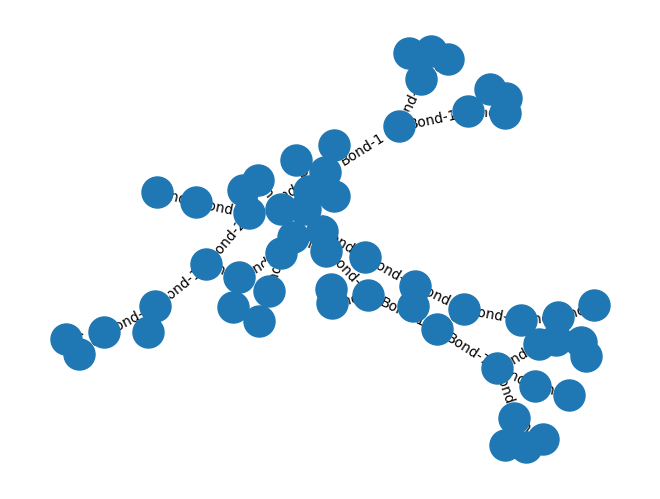

In [ ]:
pos = nx.spring_layout(G, seed=1)

node_labels = {
    n: G.nodes[n]["atom_type"]
    for n in G.nodes
}

edge_labels = {
    (u, v): G.edges[u, v]["bond_type"]
    for u, v in G.edges
}

nx.draw(
    G,
    pos,
    labels=node_labels,
    with_labels=False,
    node_size=500,
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)